In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### In which player rank range were the voters able to correctly guess the winner at a higher percentage?

In [ ]:
votes_df = pd.read_csv("../votes.csv")
match_event_df = pd.read_csv("../event.csv")
home_team_df = pd.read_csv("../home_team.csv")
away_team_df = pd.read_csv("../away_team.csv")

In [ ]:
votes_df = votes_df[["match_id", "home_vote", "away_vote"]].copy()
votes_df = votes_df.dropna(subset=["match_id", "home_vote", "away_vote"])

votes_df = votes_df[(votes_df["home_vote"] >= 0) & (votes_df["away_vote"] >= 0)]

votes_df = votes_df[votes_df["home_vote"] + votes_df["away_vote"] > 0]
votes_df = votes_df.drop_duplicates(subset=["match_id"])

- Crowd picks whoever got more votes, equal votes are excluded.  If crowd_pick = 1 means crowd picked home, and 2 means crowd picked away

In [44]:
votes_df = votes_df[votes_df["home_vote"] != votes_df["away_vote"]]
votes_df["voters_pick"] = np.where(
    votes_df["home_vote"] > votes_df["away_vote"], 1, 2)

In [45]:
match_event_df = match_event_df[["match_id", "winner_code"]].copy()
match_event_df = match_event_df.dropna(subset=["match_id", "winner_code"])
match_event_df = match_event_df[match_event_df["winner_code"].isin([1, 2])]
match_event_df = match_event_df.drop_duplicates(subset=["match_id"])

In [46]:
home_team_df = home_team_df[["match_id", "current_rank"]].copy()
away_team_df = away_team_df[["match_id", "current_rank"]].copy()

for df_ in [home_team_df, away_team_df]:
    df_.dropna(subset=["match_id", "current_rank"], inplace=True)

home_team_df = home_team_df[home_team_df["current_rank"] > 0]
away_team_df = away_team_df[away_team_df["current_rank"] > 0]
home_team_df = home_team_df.drop_duplicates(subset=["match_id"])
away_team_df = away_team_df.drop_duplicates(subset=["match_id"])

In [47]:
match_df = (votes_df
    .merge(match_event_df, on="match_id", how="inner")
    .merge(home_team_df
           .rename(columns={"current_rank": "home_rank"}), on="match_id", how="inner")
    .merge(away_team_df
           .rename(columns={"current_rank": "away_rank"}), on="match_id", how="inner"))

In [49]:
match_df["voters_correct"] = (
    match_df["voters_pick"] == match_df["winner_code"]
).astype(int)

match_df["winner_rank"] = np.where(
    match_df["winner_code"] == 1,
    match_df["home_rank"],
    match_df["away_rank"])

In [50]:
rank_bins   = [0, 10, 25, 50, 100, 200, 500, np.inf]
rank_labels = ["1-10", "11-25", "26-50", "51-100", "101-200", "201-500", "500+"]

match_df["rank_group"] = pd.cut(
    match_df["winner_rank"],
    bins=rank_bins,
    labels=rank_labels )

result = (match_df.groupby("rank_group", observed=True)
    .agg(
        total_matches=("voters_correct", "count"),
        correct_guesses=("voters_correct", "sum"),
        correct_pct=("voters_correct", "mean"))
    .reset_index()
    .assign(correct_pct=lambda d: (d["correct_pct"] * 100).round(2)))

print("\n Voters Prediction Accuracy by Winner Rank Range:\n")
print(result.to_string(index=False))



 Voters Prediction Accuracy by Winner Rank Range:

rank_group  total_matches  correct_guesses  correct_pct
      1-10            165              157        95.15
     11-25            201              150        74.63
     26-50            253              171        67.59
    51-100            536              369        68.84
   101-200           1128              807        71.54
   201-500           3160             2280        72.15
      500+           3867             2232        57.72


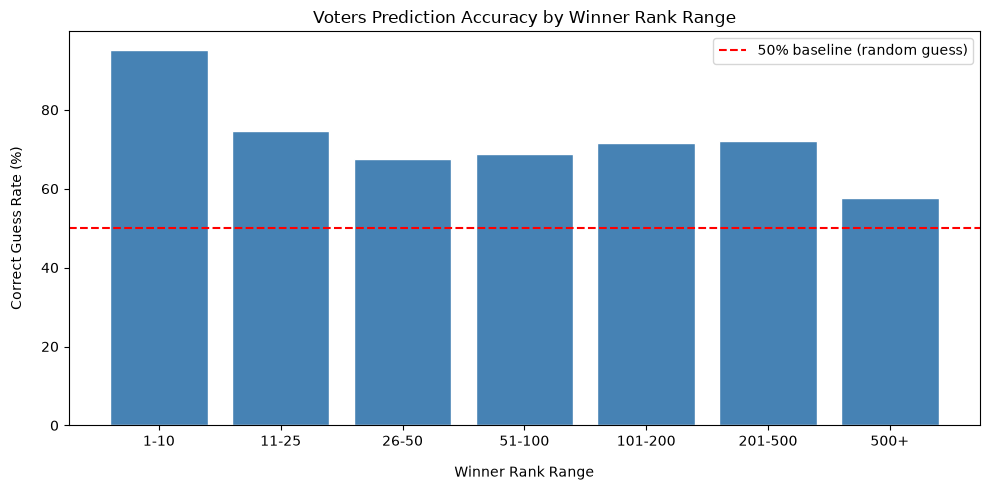

In [51]:
plt.figure(figsize=(10, 5))
plt.bar(
    result["rank_group"].astype(str),
    result["correct_pct"],
    color="steelblue",
    edgecolor="white")

plt.axhline(50, color="red", linestyle="--", label="50% baseline (random guess)")

plt.title("Voters Prediction Accuracy by Winner Rank Range")
plt.xlabel("Winner Rank Range" , labelpad=12)
plt.ylabel("Correct Guess Rate (%)" , labelpad=12)
plt.legend()
plt.tight_layout()
plt.show()